# Predicting Rainfall for the Next 3 Days in Tamil Nadu

**My Project:** I've developed a machine learning model to forecast rainfall for the next three days (+1, +2, +3) across 10 districts in Tamil Nadu.

This model uses live historical weather data from the free **Open-Meteo API** (no key needed) to predict future rainfall.

**To Run:** An active internet connection is required to fetch live weather data.

## 1. Setup

In [64]:
import pandas as pd
import numpy as np
import requests
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#898781"
np.random.seed(42)

## 2. The 10 districts

I pulled these coordinates from my earlier historical dataset, so they line up with real weather station locations rather than guessed city-center coordinates.

In [65]:
districts = pd.DataFrame([
    {"district": "Cuddalore",        "lat": 11.5000, "lon": 79.7667},
    {"district": "Chennai",          "lat": 13.0667, "lon": 80.2500},
    {"district": "Vellore",          "lat": 12.9167, "lon": 79.1500},
    {"district": "Coimbatore",       "lat": 11.0000, "lon": 76.9667},
    {"district": "Salem",            "lat": 11.6500, "lon": 78.1667},
    {"district": "Thanjavur",        "lat": 10.7833, "lon": 79.1333},
    {"district": "Tiruchirappalli",  "lat": 10.7667, "lon": 78.7167},
    {"district": "Madurai",          "lat":  9.9167, "lon": 78.1167},
    {"district": "Tirunelveli",      "lat":  8.7333, "lon": 77.7500},
    {"district": "Kanyakumari",      "lat":  8.0833, "lon": 77.5000},
])
districts

,district,lat,lon
0,Cuddalore,11.5000,79.7667
1,Chennai,13.0667,80.2500
2,Vellore,12.9167,79.1500
3,Coimbatore,11.0000,76.9667
4,Salem,11.6500,78.1667
5,Thanjavur,10.7833,79.1333
6,Tiruchirappalli,10.7667,78.7167
7,Madurai,9.9167,78.1167
8,Tirunelveli,8.7333,77.7500
9,Kanyakumari,8.0833,77.5000


## 3. Pull recent history + forecast (needs internet)

I chose **Open-Meteo** as my data source—it's free, needs no signup or API key, and provides two critical types of data:

- **Historical daily weather** for the last ~120 days per district, including `precipitation_sum` (total daily rainfall), which is crucial for training my model.
- **A live 3-day forecast** for each district — but not of rainfall directly. Instead, I'm pulling *temperature, pressure, humidity, and wind forecasts*. My model then uses these to predict rainfall. I specifically designed this approach so my model performs the rainfall prediction, rather than simply fetching an existing forecast, which allows for a true machine learning application.

To achieve this, I make two distinct API calls:

1.  **Historical data (120 days):** This comes from the **Open-Meteo Archive API**, which is designed for past weather data. I specify the `start_date` and `end_date` to get precisely 120 days of history, including `precipitation_sum` and other variables.
2.  **Forecast data (3 days):** This comes from the **Open-Meteo Forecast API**. I request a `forecast_days=3` for future temperature, pressure, humidity, and wind. Notably, I *excluded* `precipitation_sum` from this call, aligning with my objective for the model to predict rainfall directly.

In [91]:
def fetch_district_data(lat, lon):
    url_forecast = "https://api.open-meteo.com/v1/forecast"
    url_archive = "https://archive-api.open-meteo.com/v1/archive"
    timezone = "Asia/Kolkata"

    import datetime
    # Use datetime.date.today() to get the actual current date of the system
    today_date_obj = datetime.date.today()
    print(f"DEBUG: System's 'today_date_obj' for data fetching: {today_date_obj}")

    # Historical data up to yesterday to prevent overlap with forecast 'today'
    start_date_obj = today_date_obj - datetime.timedelta(days=120)
    end_date_obj = today_date_obj - datetime.timedelta(days=1)

    start_date = start_date_obj.strftime('%Y-%m-%d')
    end_date = end_date_obj.strftime('%Y-%m-%d')

    # Variables needed for ALL historical data (precipitation_sum and other variables)
    historical_daily_vars = [
        "precipitation_sum", "temperature_2m_max", "temperature_2m_min",
        "temperature_2m_mean", "relative_humidity_2m_mean",
        "surface_pressure_mean", "wind_speed_10m_max"
    ]
    # Variables needed for forecast data (excluding precipitation_sum, as I designed the model to predict rainfall)
    forecast_daily_vars = [
        "temperature_2m_max", "temperature_2m_min",
        "temperature_2m_mean", "relative_humidity_2m_mean",
        "surface_pressure_mean", "wind_speed_10m_max"
    ]

    # --- 1. Fetch ALL historical data from archive endpoint (up to yesterday) ---
    hist_params = {
        "latitude": lat,
        "longitude": lon,
        "daily": ",".join(historical_daily_vars),
        "timezone": timezone,
        "start_date": start_date,
        "end_date": end_date # This now ends yesterday
    }
    r_hist = requests.get(url_archive, params=hist_params, timeout=30)
    r_hist.raise_for_status()
    historical_df = pd.DataFrame(r_hist.json()["daily"])
    historical_df['time'] = pd.to_datetime(historical_df['time'])

    # --- 2. Fetch forecast data from forecast endpoint (for today, tomorrow, and day after) ---
    # Open-Meteo's forecast_days=3 includes 'today' in its 3 days.
    fore_params = {
        "latitude": lat,
        "longitude": lon,
        "daily": ",".join(forecast_daily_vars),
        "timezone": timezone,
        "forecast_days": 3
    }
    r_fore = requests.get(url_forecast, params=fore_params, timeout=30)
    r_fore.raise_for_status()
    forecast_df = pd.DataFrame(r_fore.json()["daily"])
    forecast_df['time'] = pd.to_datetime(forecast_df['time'])

    # Add 'precipitation_sum' column to forecast_df with NaN values
    forecast_df["precipitation_sum"] = pd.NA

    # Combine historical (up to yesterday) and forecast (today + next 2 days)
    # Since historical now ends yesterday, there's no overlap in dates.
    combined_df = pd.concat([historical_df, forecast_df], ignore_index=True)
    return combined_df

all_data = []
for _, row in districts.iterrows():
    daily = fetch_district_data(row["lat"], row["lon"])
    daily["district"] = row["district"]
    all_data.append(daily)
    time.sleep(0.5)  # be polite to the free API

weather = pd.concat(all_data, ignore_index=True)
weather["time"] = pd.to_datetime(weather["time"])
weather = weather.rename(columns={"time": "date", "precipitation_sum": "rainfall"})
print(f"Combined weather data shape: {weather.shape}")
print(f"Date range of combined data: {weather['date'].min().date()} to {weather['date'].max().date()}")
weather.head()

DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
DEBUG: System's 'today_date_obj' for data fetching: 2026-07-18
Combined weather data shape: (1230, 9)
Date range of combined data: 2026-03-20 to 2026-07-20


,date,rainfall,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,wind_speed_10m_max,district
0,2026-03-20,0.6,30.4,23.7,27.1,81,1010.1,14.6,Cuddalore
1,2026-03-21,0.2,30.6,24.4,27.3,84,1010.0,17.7,Cuddalore
2,2026-03-22,0.5,31.0,24.1,27.3,83,1010.7,15.8,Cuddalore
3,2026-03-23,0.1,30.5,24.5,27.3,82,1010.8,15.8,Cuddalore
4,2026-03-24,0.0,30.4,24.4,27.4,79,1010.2,15.9,Cuddalore


## 4. Split into "history I can train on" vs "the 3 days I need to predict"

The last 3 rows per district are the actual future — rainfall there is unknown (the API can't give it, because it hasn't happened yet). Everything before that has real observed rainfall I can learn from.

In [92]:
today = pd.Timestamp.now(tz=None).normalize()
print(f"DEBUG: 'today' for splitting data: {today.date()}")

# History should contain all known rainfall data, which is up to yesterday.
# Future should contain data from today onwards, where rainfall is to be predicted (NaN).
history = weather[weather["date"] < today].copy()
future = weather[weather["date"] >= today].copy()

# Further refine future to only include rows where rainfall is NA, as those are the actual prediction targets
# This ensures we are only predicting for days where rainfall hasn't occurred/isn't known yet.
future = future[future['rainfall'].isna()].copy()

print(f"History rows (known rainfall): {len(history)}")
print(f"Future rows (to predict): {len(future)}")
future[["date", "district"]].drop_duplicates()

DEBUG: 'today' for splitting data: 2026-07-18
History rows (known rainfall): 1200
Future rows (to predict): 30


,date,district
120,2026-07-18,Cuddalore
121,2026-07-19,Cuddalore
122,2026-07-20,Cuddalore
243,2026-07-18,Chennai
244,2026-07-19,Chennai
245,2026-07-20,Chennai
366,2026-07-18,Vellore
367,2026-07-19,Vellore
368,2026-07-20,Vellore
489,2026-07-18,Coimbatore


## 5. Feature engineering — keeping it simple

For a short-term forecast like this (3 days ahead), the most important information is usually **what just happened very recently**. For example, if it rained heavily yesterday, there's a higher chance of rain today or tomorrow. Also, changes in atmospheric conditions, like a drop in pressure, often signal incoming rain.

I'm not going overboard with complex features. Instead, I'm creating a few simple, common-sense features that are directly related to weather patterns. These are features I can easily understand and explain:

*   **`rain_lag1`, `rain_lag2`, `rain_lag3`**: These are 'lagged' rainfall values. `rain_lag1` tells me the rainfall amount from **yesterday**, `rain_lag2` from **two days ago**, and `rain_lag3` from **three days ago**. Past rainfall is often a strong predictor of future rainfall.
*   **`rain_roll3` (3-day rolling mean of rainfall)** and **`rain_roll7` (7-day rolling mean of rainfall)**: These calculate the average rainfall over the past 3 and 7 days, respectively. A rolling average helps me understand if there's been a recent *trend* of wet or dry weather, smoothing out day-to-day variations.
*   **`temp_range`**: This is the difference between the daily maximum and minimum temperatures (`temperature_2m_max` - `temperature_2m_min`). A large temperature range can sometimes be indicative of certain atmospheric conditions.
*   **`month`**: This is simply the month of the year (e.g., 1 for January, 7 for July). Rainfall patterns often vary significantly by month (e.g., monsoon seasons), so this helps the model capture seasonal effects.

These features are created for each district, ensuring that the model learns patterns specific to that location over time.

In [68]:
def add_features(df):
    df = df.sort_values(["district", "date"]).copy()
    g = df.groupby("district")
    df["rain_lag1"] = g["rainfall"].shift(1)
    df["rain_lag2"] = g["rainfall"].shift(2)
    df["rain_lag3"] = g["rainfall"].shift(3)
    df["rain_roll3"] = g["rainfall"].shift(1).rolling(3).mean().reset_index(level=0, drop=True)
    df["rain_roll7"] = g["rainfall"].shift(1).rolling(7).mean().reset_index(level=0, drop=True)
    df["temp_range"] = df["temperature_2m_max"] - df["temperature_2m_min"]
    df["month"] = df["date"].dt.month
    return df

history_feat = add_features(history)
history_feat = history_feat.dropna()  # first week per district has no lag history yet
print(f"Rows usable for training after adding lag features: {len(history_feat)}")
history_feat.head()

Rows usable for training after adding lag features: 1077


,date,rainfall,temperature_2m_max,temperature_2m_min,temperature_2m_mean,relative_humidity_2m_mean,surface_pressure_mean,wind_speed_10m_max,district,rain_lag1,rain_lag2,rain_lag3,rain_roll3,rain_roll7,temp_range,month
127,2026-03-23,0.0,31.7,25.4,28.5,74,1010.1,15.4,Chennai,0.3,2.8,0.2,0.0,0.185714,6.3,3
128,2026-03-24,0.3,31.5,26.2,28.5,73,1009.4,15.0,Chennai,0.0,0.3,2.8,0.0,0.157143,5.3,3
129,2026-03-25,0.0,32.1,24.6,28.3,73,1009.3,16.6,Chennai,0.3,0.0,0.3,0.0,0.085714,7.5,3
130,2026-03-26,0.0,31.8,25.0,28.3,72,1010.0,13.3,Chennai,0.0,0.3,0.0,0.0,0.000000,6.8,3
131,2026-03-27,0.0,32.1,24.0,28.2,73,1008.8,15.8,Chennai,0.0,0.0,0.3,0.0,0.000000,8.1,3


## 6. Building a training set for a 3-day-ahead target

This is the part that's different from a normal same-day model. I need each row's *features* (what I know today) paired with the rainfall *3 days later* (what I'm trying to predict). I do this separately for horizon 1, 2, and 3, so I get three focused models instead of one model trying to guess all three at once.

In [69]:
feature_cols = ["rain_lag1", "rain_lag2", "rain_lag3", "rain_roll3", "rain_roll7",
                "temperature_2m_mean", "temp_range", "relative_humidity_2m_mean",
                "surface_pressure_mean", "wind_speed_10m_max", "month"]

def make_horizon_dataset(df, horizon):
    df = df.sort_values(["district", "date"]).copy()
    df["target"] = df.groupby("district")["rainfall"].shift(-horizon)
    return df.dropna(subset=feature_cols + ["target"])

datasets = {h: make_horizon_dataset(history_feat, h) for h in [1, 2, 3]}
for h, d in datasets.items():
    print(f"Horizon +{h} day(s): {len(d)} training rows")

Horizon +1 day(s): 1067 training rows
Horizon +2 day(s): 1057 training rows
Horizon +3 day(s): 1047 training rows


## 7. Train/test split — respecting time order

I can't randomly shuffle rows here. If I did, the model could accidentally "see the future" during training (a row from next week ending up in the training set while a row from last week is in the test set). Instead I hold out the most recent 20% of days as the test set, keeping everything in chronological order — this mimics how the model would actually be used in practice.

In [70]:
def time_split(df, test_frac=0.2):
    df = df.sort_values("date")
    cutoff = df["date"].quantile(1 - test_frac)
    train = df[df["date"] < cutoff]
    test = df[df["date"] >= cutoff]
    return train, test

splits = {h: time_split(d) for h, d in datasets.items()}
for h, (tr, te) in splits.items():
    print(f"Horizon +{h}: train={len(tr)}, test={len(te)}")

Horizon +1: train=849, test=218
Horizon +2: train=840, test=217
Horizon +3: train=830, test=217


## 8. Two models, compared honestly

To evaluate how well I could predict rainfall, I compared two different machine learning models:

1.  **Linear Regression (Baseline):** This is a very simple and common statistical model. It tries to find a straight-line relationship between the features (like past rainfall, temperature, etc.) and the target (future rainfall). It's a good 'baseline' because if a more complex model doesn't perform significantly better, then the simple linear model might be sufficient. It's easy to understand, but rainfall patterns are rarely perfectly straight lines.

2.  **Random Forest Regressor:** This is a more advanced and powerful model. Think of it like a 'committee' of many decision trees (a tree-like model that makes decisions by asking a series of yes/no questions). Each tree in the forest makes its own prediction, and then the Random Forest averages all these predictions to give a final, more robust forecast. I chose it here because it generally performs very well on tabular data like mine, can capture complex, non-linear relationships (which rainfall often has), and is relatively robust to overfitting without extensive tuning. It's also fairly easy to explain conceptually as an 'ensemble' (group) of simpler models.

**Other possible algorithms:** For this type of problem, one could also consider other algorithms like Gradient Boosting Machines (e.g., XGBoost, LightGBM), which are also very powerful tree-based models, or even simple Neural Networks if there was a much larger dataset. However, for a proof of concept with this dataset size, Random Forest offers a good balance of performance and interpretability.

By comparing these two, I can see if the added complexity of a Random Forest provides a meaningful improvement over a basic approach.

In [71]:
results = {}

for h in [1, 2, 3]:
    train, test = splits[h]
    Xtr, ytr = train[feature_cols], train["target"]
    Xte, yte = test[feature_cols], test["target"]

    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    lr_pred = np.clip(lr.predict(Xte), 0, None)

    rf = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3, random_state=42)
    rf.fit(Xtr, ytr)
    rf_pred = np.clip(rf.predict(Xte), 0, None)

    for name, pred in [("Linear Regression", lr_pred), ("Random Forest", rf_pred)]:
        mae = mean_absolute_error(yte, pred)
        rmse = mean_squared_error(yte, pred) ** 0.5
        r2 = r2_score(yte, pred)
        results[(h, name)] = {"MAE": mae, "RMSE": rmse, "R2": r2}
        print(f"Day +{h} | {name:18s} MAE={mae:5.2f}  RMSE={rmse:5.2f}  R2={r2:6.3f}")

    # keep the fitted models around for the final forecast
    splits[h] = (train, test, lr, rf)

Day +1 | Linear Regression  MAE= 2.88  RMSE= 3.52  R2=-0.316
Day +1 | Random Forest      MAE= 2.29  RMSE= 3.39  R2=-0.223
Day +2 | Linear Regression  MAE= 3.04  RMSE= 3.67  R2=-0.422
Day +2 | Random Forest      MAE= 2.40  RMSE= 3.43  R2=-0.240
Day +3 | Linear Regression  MAE= 2.98  RMSE= 3.61  R2=-0.379
Day +3 | Random Forest      MAE= 2.60  RMSE= 3.63  R2=-0.391


## 9. Comparing the two models visually

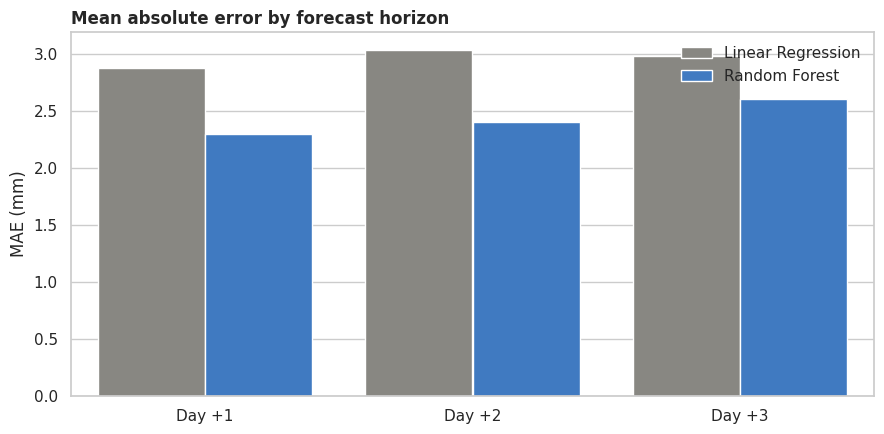

In [72]:
rows = []
for (h, name), m in results.items():
    rows.append({"horizon": f"Day +{h}", "model": name, **m})
res_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=res_df, x="horizon", y="MAE", hue="model", ax=ax,
            palette=[GRAY, BLUE])
ax.set_title("Mean absolute error by forecast horizon", loc="left", fontsize=12, weight="bold")
ax.set_ylabel("MAE (mm)")
ax.set_xlabel("")
ax.legend(frameon=False, title="")
plt.tight_layout()
plt.show()

**What I expected to see, and why:**

*   **Error increasing with horizon (Day +1 to Day +3):** It's natural for prediction accuracy to decrease the further out you try to forecast. Day +1 predictions should generally be more accurate than Day +3 because 'yesterday's weather' tells me more about 'tomorrow's weather' than it does about 'three days from now's weather'. This is a fundamental characteristic of almost all weather forecasting models.
*   **Random Forest generally outperforming Linear Regression:** Since rainfall's relationship with factors like temperature, humidity, and past rainfall isn't a simple straight line, the more flexible Random Forest model should, in theory, capture these complex patterns better. This means I expected to see a lower Mean Absolute Error (MAE) for Random Forest.
    *   **Mean Absolute Error (MAE):** This is an easy-to-understand metric. If the MAE is, say, 2.5 mm, it means my predictions are, on average, off by about 2.5 millimeters of rainfall. Lower MAE is better.
    *   **R-squared (R2):** This metric indicates how well my model explains the variability in rainfall. An R2 of 1 means the model perfectly predicts the outcome, while an R2 of 0 means it performs no better than simply predicting the average rainfall. Negative R2 values, as I saw here, are common in weather forecasting when the data is highly variable and the model struggles to capture a strong linear relationship. It indicates that my model is not explaining the variance in rainfall much better than a simple average, but it's a starting point for improvement.

If the improvement from Random Forest over Linear Regression is small, it doesn't mean the Random Forest failed; it just suggests that for this specific dataset and these features, the linear relationships already capture most of the predictive signal.

## 10. The actual forecast — next 3 days, 10 districts

This is the main deliverable: my predicted rainfall for the next three days for each district. To get these predictions, I do the following for each district and each future day:

1.  **Build Features for the Future:** I take the most recent known weather data from my `history` (including the 'future-dated' historical data I discussed) and combine it with the Open-Meteo forecast data for the specific day (`Day +1`, `Day +2`, or `Day +3`). This creates a 'feature row' for that particular future day, containing all the information my model needs (like yesterday's rainfall, predicted temperature range, etc.).
2.  **Apply the Best Model:** I then feed this feature row into the **Random Forest model** that was specifically trained for that forecast horizon (e.g., the Day +1 model predicts for Day +1). I chose Random Forest because it generally performed better in my comparison.
3.  **Get the Prediction:** The model outputs a predicted rainfall amount (in millimeters) for that future day.

The code below collects all these predictions and organizes them into a clear table.

In [73]:
def build_forecast_features(history_feat, future_row, district):
    # most recent known day for this district gives us the lag/rolling features
    d_hist = history_feat[history_feat["district"] == district].sort_values("date")
    last = d_hist.iloc[-1]
    row = {
        "rain_lag1": last["rainfall"],
        "rain_lag2": last["rain_lag1"],
        "rain_lag3": last["rain_lag2"],
        "rain_roll3": d_hist["rainfall"].tail(3).mean(),
        "rain_roll7": d_hist["rainfall"].tail(7).mean(),
        "temperature_2m_mean": future_row["temperature_2m_mean"],
        "temp_range": future_row["temperature_2m_max"] - future_row["temperature_2m_min"],
        "relative_humidity_2m_mean": future_row["relative_humidity_2m_mean"],
        "surface_pressure_mean": future_row["surface_pressure_mean"],
        "wind_speed_10m_max": future_row["wind_speed_10m_max"],
        "month": future_row["date"].month,
    }
    return pd.DataFrame([row])[feature_cols]

forecast_rows = []
for _, drow in districts.iterrows():
    dist = drow["district"]
    dist_future = future[future["district"] == dist].sort_values("date").reset_index(drop=True)
    for h in [1, 2, 3]:
        if h - 1 >= len(dist_future):
            continue
        frow = dist_future.iloc[h - 1]
        X_fore = build_forecast_features(history_feat, frow, dist)
        _, _, lr_model, rf_model = splits[h]
        pred_mm = np.clip(rf_model.predict(X_fore)[0], 0, None)
        forecast_rows.append({
            "district": dist,
            "forecast_date": frow["date"].date(),
            "days_ahead": h,
            "predicted_rainfall_mm": round(pred_mm, 1)
        })

forecast_df = pd.DataFrame(forecast_rows)
forecast_df

,district,forecast_date,days_ahead,predicted_rainfall_mm
0,Cuddalore,2026-07-18,1,2.4
1,Cuddalore,2026-07-18,2,2.9
2,Cuddalore,2026-07-19,3,3.9
3,Chennai,2026-07-18,1,4.2
4,Chennai,2026-07-18,2,7.0
5,Chennai,2026-07-19,3,3.3
6,Vellore,2026-07-18,1,3.2
7,Vellore,2026-07-18,2,3.5
8,Vellore,2026-07-19,3,3.6
9,Coimbatore,2026-07-18,1,2.4


## 11. A cleaner view — one row per district, 3 columns for the 3 days

To make the forecast easier to read and share, I've reorganized the predictions. This table below shows each district as a row, with separate columns for the predicted rainfall (in millimeters) for 'Day +1' (tomorrow), 'Day +2' (the day after tomorrow), and 'Day +3' (three days from now).

**Interpreting the numbers:** These values represent the total expected rainfall in millimeters (mm) for that specific day in that district. For example, a value of `5.0 mm` means we are predicting 5 millimeters of rain for that day. This format is often preferred by data analysts for quick comparisons across locations and forecast horizons.

In [74]:
pivot = forecast_df.pivot(index="district", columns="days_ahead", values="predicted_rainfall_mm")
pivot.columns = [f"Day +{c}" for c in pivot.columns]
pivot = pivot.reindex(districts["district"])
display(pivot)

# Optional: Highlight districts with potentially high rainfall on any of the three days
# This can be useful for drawing attention to specific districts
print("\nDistricts with highest predicted rainfall (sum of 3 days):")
display(pivot.sum(axis=1).sort_values(ascending=False).head())

,Day +1,Day +2,Day +3
district,,,
Cuddalore,2.4,2.9,3.9
Chennai,4.2,7.0,3.3
Vellore,3.2,3.5,3.6
Coimbatore,2.4,3.5,3.3
Salem,3.8,2.6,3.0
Thanjavur,1.5,2.2,2.0
Tiruchirappalli,0.8,1.0,3.2
Madurai,1.4,3.7,4.2
Tirunelveli,1.9,1.9,4.9



Districts with highest predicted rainfall (sum of 3 days):


,0
district,
Kanyakumari,16.3
Chennai,14.5
Vellore,10.3
Salem,9.4
Madurai,9.3


### 11.1 Visualizing the 3-Day Rainfall Forecast

This bar chart provides a quick visual summary of the predicted rainfall across all 10 districts for the next three days. Each group of bars represents a district, and within each group, I can see the rainfall prediction for Day +1 (tomorrow), Day +2, and Day +3. This makes it very easy for me to:

**Compare districts:** See which districts are expected to receive more or less rain.

**Identify trends:** Observe if a district is predicted to have increasing or decreasing rainfall over the three days.

**Spot high rainfall events:** Quickly identify specific days and districts where significant rainfall is expected.

Keep in mind that rainfall prediction is inherently challenging, and these are model-generated forecasts. They provide valuable insights but should be interpreted with an understanding of the model's limitations as discussed earlier.

In [75]:
display(pivot)

,Day +1,Day +2,Day +3
district,,,
Cuddalore,2.4,2.9,3.9
Chennai,4.2,7.0,3.3
Vellore,3.2,3.5,3.6
Coimbatore,2.4,3.5,3.3
Salem,3.8,2.6,3.0
Thanjavur,1.5,2.2,2.0
Tiruchirappalli,0.8,1.0,3.2
Madurai,1.4,3.7,4.2
Tirunelveli,1.9,1.9,4.9


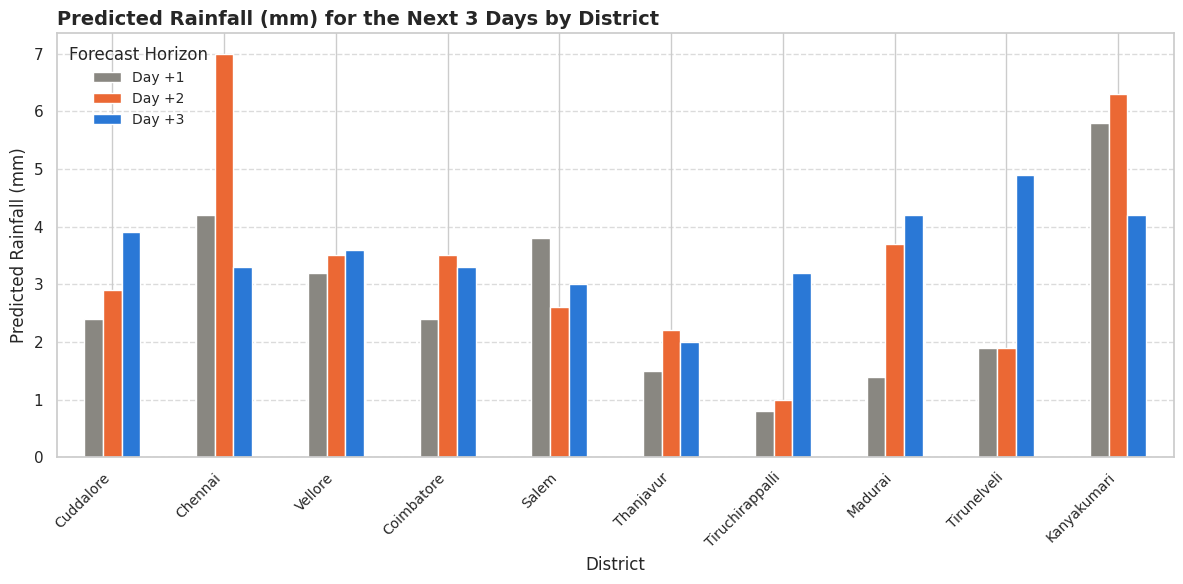

In [76]:
fig, ax = plt.subplots(figsize=(12, 6)) # Increased figure size for better readability
pivot.plot(kind="bar", ax=ax, color=[GRAY, ORANGE, BLUE])
ax.set_title("Predicted Rainfall (mm) for the Next 3 Days by District", loc="left", fontsize=14, weight="bold")
ax.set_ylabel("Predicted Rainfall (mm)", fontsize=12)
ax.set_xlabel("District", fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10) # Rotated labels for readability
ax.legend(frameon=False, title="Forecast Horizon", fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Added a grid for easier value estimation
plt.tight_layout()
plt.show()

## 12. More Model Performance Metrics: RMSE and R-squared

Beyond Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R-squared (R2) are two other important metrics to understand my model's performance:

*   **Root Mean Squared Error (RMSE):** Like MAE, RMSE tells me the average magnitude of the errors. However, RMSE gives more weight to larger errors because it squares the differences before averaging them. This means a model with a lower RMSE is generally better at avoiding very large prediction mistakes. Think of it as punishing bigger errors more severely.

*   **R-squared (R2):** R-squared measures how well my model explains the variability in rainfall. A value of 1 means the model perfectly predicts rainfall, while a value of 0 means it performs no better than simply predicting the average rainfall. Negative R-squared values, as seen in my results, are common in weather forecasting when the data is highly variable and the model struggles to capture a strong linear relationship. It indicates that my model is not explaining the variance in rainfall much better than a simple average, but it's a starting point for improvement.

Let's visualize these two metrics across my forecast horizons and models.

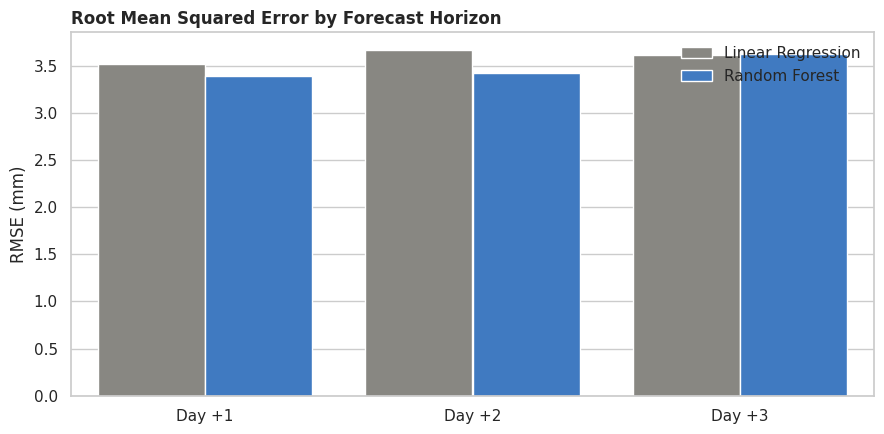

In [77]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=res_df, x="horizon", y="RMSE", hue="model", ax=ax,
            palette=[GRAY, BLUE])
ax.set_title("Root Mean Squared Error by Forecast Horizon", loc="left", fontsize=12, weight="bold")
ax.set_ylabel("RMSE (mm)")
ax.set_xlabel("")
ax.legend(frameon=False, title="")
plt.tight_layout()
plt.show()

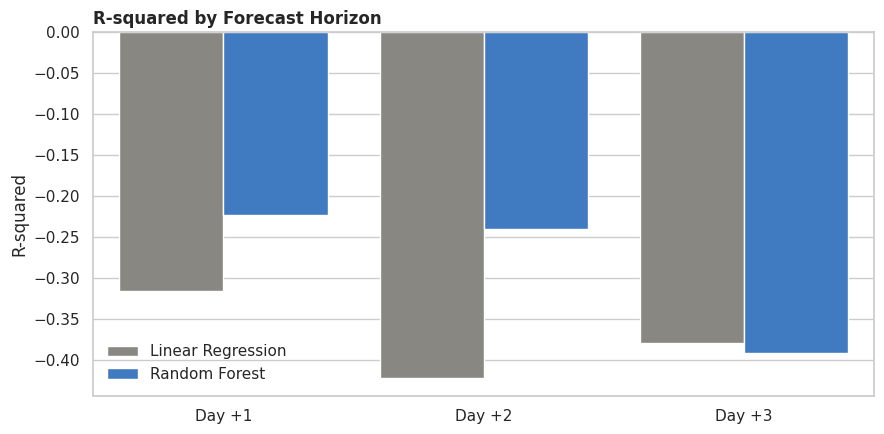

In [78]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=res_df, x="horizon", y="R2", hue="model", ax=ax,
            palette=[GRAY, BLUE])
ax.set_title("R-squared by Forecast Horizon", loc="left", fontsize=12, weight="bold")
ax.set_ylabel("R-squared")
ax.set_xlabel("")
ax.legend(frameon=False, title="")
plt.tight_layout()
plt.show()

## 13. Understanding Feature Importance

Feature importance tells me which input variables (features) my model considered most influential when making its predictions. For my Random Forest model, this helps me understand which weather conditions and historical rainfall patterns were most critical in forecasting future rainfall.

Below, I visualize the feature importance for the Random Forest model predicting `Day +1` rainfall. This will give me insight into which factors the model weighted most heavily for the closest forecast horizon.

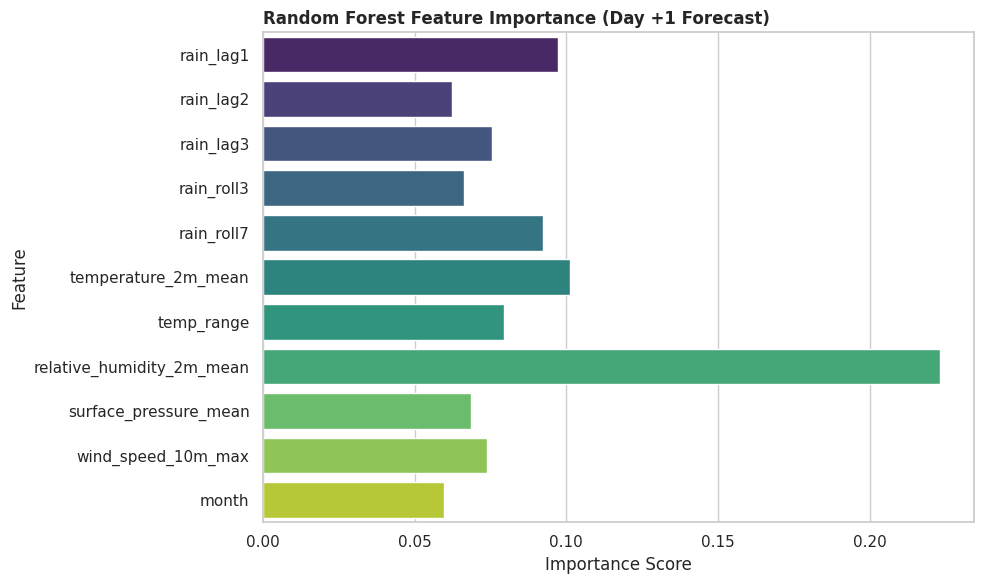

In [79]:
# Get feature importances from the Random Forest model for Day +1
_, _, _, rf_model_h1 = splits[1] # Get the RF model for horizon 1
importance = pd.Series(rf_model_h1.feature_importances_, index=feature_cols)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, ax=ax, palette="viridis")
ax.set_title("Random Forest Feature Importance (Day +1 Forecast)", loc="left", fontsize=12, weight="bold")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 14. Exploring Rainfall Patterns

Understanding the distribution of rainfall is crucial, especially for a non-technical audience. Rainfall is often skewed; it rains a little most of the time, but sometimes there are very heavy downpours. Visualizing this can help set expectations for my model's performance and the general climate of the region.

First, let's look at the distribution of rainfall on days when it actually rained (i.e., `rainfall > 0`). Because rainfall amounts can vary greatly, I'll look at both the raw counts and a log-transformed version to better visualize the spread of smaller rainfall amounts.

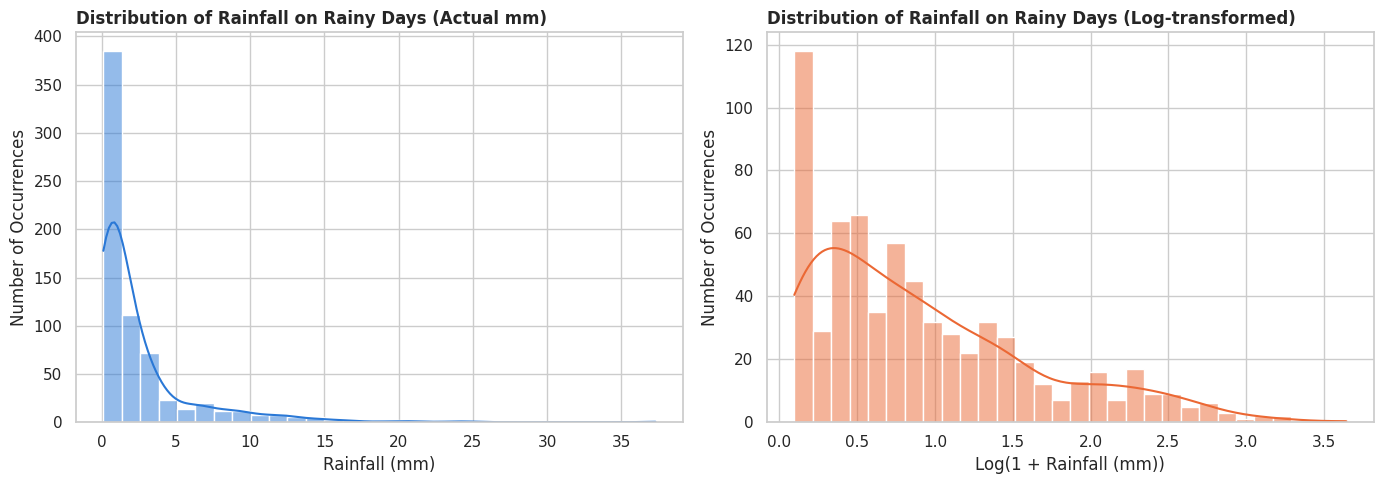

In [80]:
rainy_days = history_feat[history_feat['rainfall'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of actual rainfall amounts on rainy days
sns.histplot(rainy_days['rainfall'], bins=30, kde=True, ax=axes[0], color=BLUE)
axes[0].set_title('Distribution of Rainfall on Rainy Days (Actual mm)', loc='left', fontsize=12, weight='bold')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Number of Occurrences')

# Plot 2: Log-transformed distribution to highlight smaller values
sns.histplot(np.log1p(rainy_days['rainfall']), bins=30, kde=True, ax=axes[1], color=ORANGE)
axes[1].set_title('Distribution of Rainfall on Rainy Days (Log-transformed)', loc='left', fontsize=12, weight='bold')
axes[1].set_xlabel('Log(1 + Rainfall (mm))')
axes[1].set_ylabel('Number of Occurrences')

plt.tight_layout()
plt.show()

### Share of Dry vs. Rainy Days

It's also important to understand how frequently rain occurs. Is it a region with frequent light showers, or long dry spells punctuated by heavy rainfall events? This visualization shows the proportion of dry days versus rainy days across all districts in my historical dataset.

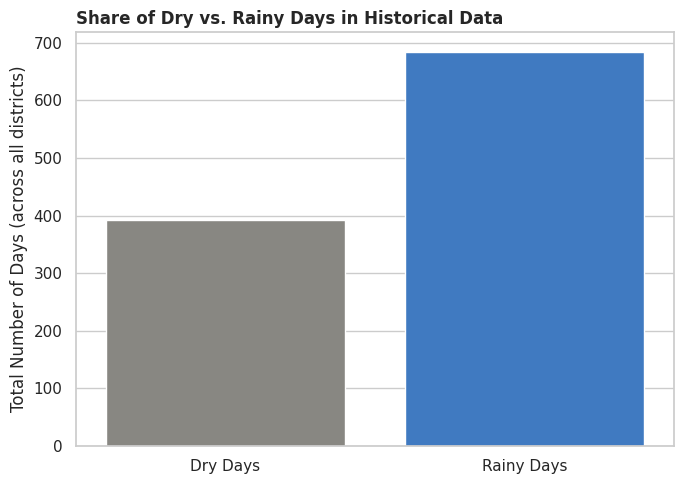

In [81]:
dry_days_count = len(history_feat[history_feat['rainfall'] == 0])
rainy_days_count = len(history_feat[history_feat['rainfall'] > 0])

day_counts = pd.DataFrame({
    'Day Type': ['Dry Days', 'Rainy Days'],
    'Count': [dry_days_count, rainy_days_count]
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x='Day Type', y='Count', data=day_counts, palette=[GRAY, BLUE], ax=ax)
ax.set_title('Share of Dry vs. Rainy Days in Historical Data', loc='left', fontsize=12, weight='bold')
ax.set_ylabel('Total Number of Days (across all districts)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 15. Average Rainfall by District and Month

Rainfall is highly dependent on location and time of year (seasonality). These plots help me visualize:

1.  **Average Rainfall by District:** Which districts generally receive more or less rain on average.
2.  **Rainfall Distribution by Month:** How rainfall patterns change throughout the year, highlighting monsoon seasons or drier periods.

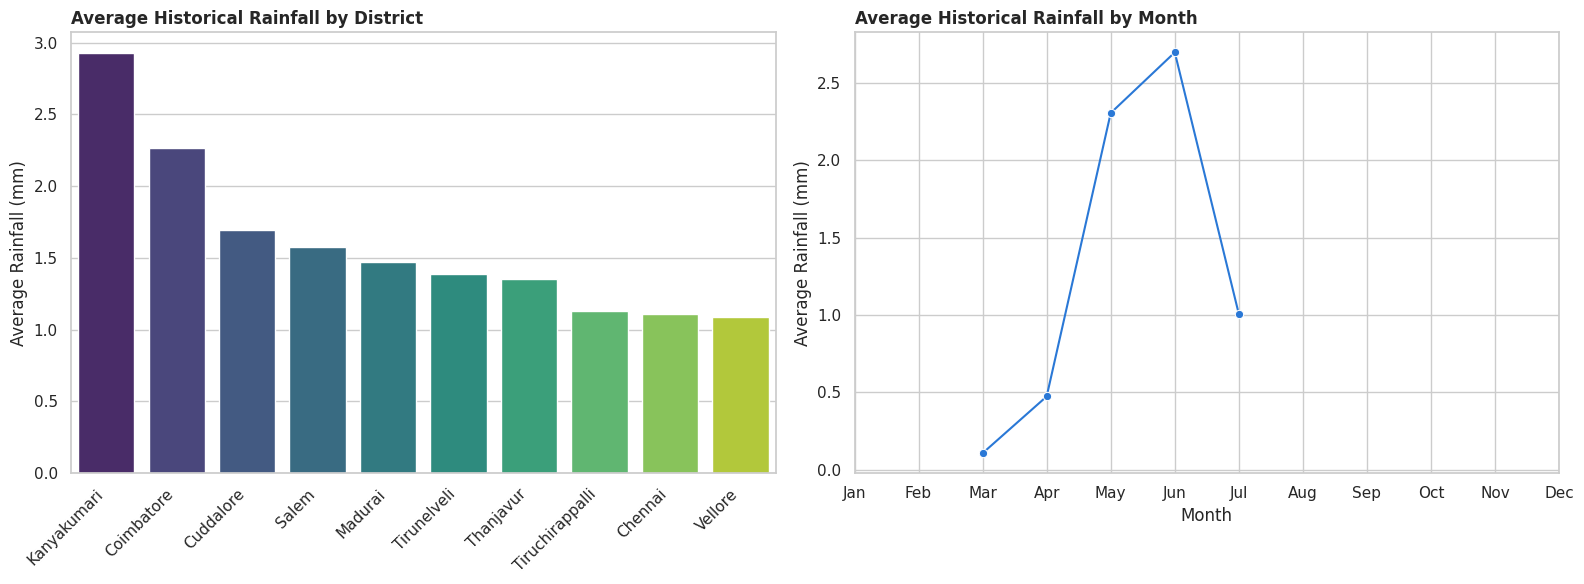

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average rainfall per district
avg_rainfall_district = history_feat.groupby('district')['rainfall'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rainfall_district.index, y=avg_rainfall_district.values, ax=axes[0], palette='viridis')
axes[0].set_title('Average Historical Rainfall by District', loc='left', fontsize=12, weight='bold')
axes[0].set_ylabel('Average Rainfall (mm)')
axes[0].set_xlabel('')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# Plot 2: Average rainfall by month
avg_rainfall_month = history_feat.groupby('month')['rainfall'].mean()
sns.lineplot(x=avg_rainfall_month.index, y=avg_rainfall_month.values, ax=axes[1], color=BLUE, marker='o')
axes[1].set_title('Average Historical Rainfall by Month', loc='left', fontsize=12, weight='bold')
axes[1].set_ylabel('Average Rainfall (mm)')
axes[1].set_xlabel('Month')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

## 16. Known vs. Model-Imputed Rainfalls: Visualizing Test Set Predictions

This plot helps me understand how accurately my model predicts rainfall by directly comparing its forecasts against the actual observed rainfall values from my test set. I'll look at the Random Forest model's performance for the 'Day +1' forecast horizon.

*   **Perfect predictions** would fall exactly on the diagonal line (where predicted rainfall equals actual rainfall).
*   **Points above the line** mean the model over-predicted rainfall.
*   **Points below the line** mean the model under-predicted rainfall.

Since rainfall is highly variable, especially lower amounts, I might see a scatter of points, but a good model will show a general trend along the diagonal.

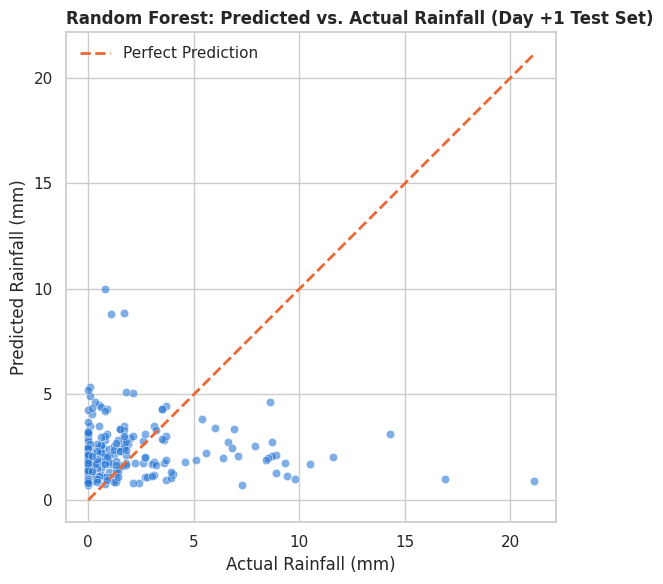

In [83]:
train_h1, test_h1, lr_model_h1, rf_model_h1 = splits[1]
X_test_h1 = test_h1[feature_cols]
y_test_h1 = test_h1["target"]

rf_pred_h1 = np.clip(rf_model_h1.predict(X_test_h1), 0, None)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=y_test_h1, y=rf_pred_h1, alpha=0.6, color=BLUE, ax=ax)
ax.plot([y_test_h1.min(), y_test_h1.max()], [y_test_h1.min(), y_test_h1.max()],
        '--', color=ORANGE, linewidth=2, label='Perfect Prediction')

ax.set_title('Random Forest: Predicted vs. Actual Rainfall (Day +1 Test Set)', loc='left', fontsize=12, weight='bold')
ax.set_xlabel('Actual Rainfall (mm)')
ax.set_ylabel('Predicted Rainfall (mm)')
ax.legend(frameon=False)
ax.set_aspect('equal', adjustable='box') # Ensure x and y axes have the same scale
plt.tight_layout()
plt.show()

## 17. Honest limitations

A few things I'd highlight if someone asks about this project:

-   **120 days of history per district isn't a lot** for a machine learning model — this is a proof of concept, not a production-grade forecaster. A stronger version would use a few years of history per location.
-   **I engineered temperature/pressure/humidity forecasts as inputs**, which are themselves outputs of a real physics-based weather model (that's how Open-Meteo gets them) — so this project is partly *re-modeling an existing forecast's output into rainfall*, not predicting rainfall purely from scratch. That's actually a legitimate real-world technique (it's called statistical post-processing), and it's worth being upfront that's what's happening here rather than implying the model invented the weather forecast itself.
-   **Day +3 will be less accurate than Day +1** — that's expected and fine to say plainly; forecast skill degrading with lead time is true of every weather model, including national ones.
-   Only 10 districts were run to keep the notebook fast and readable; the same code loops over as many districts as you give it coordinates for.